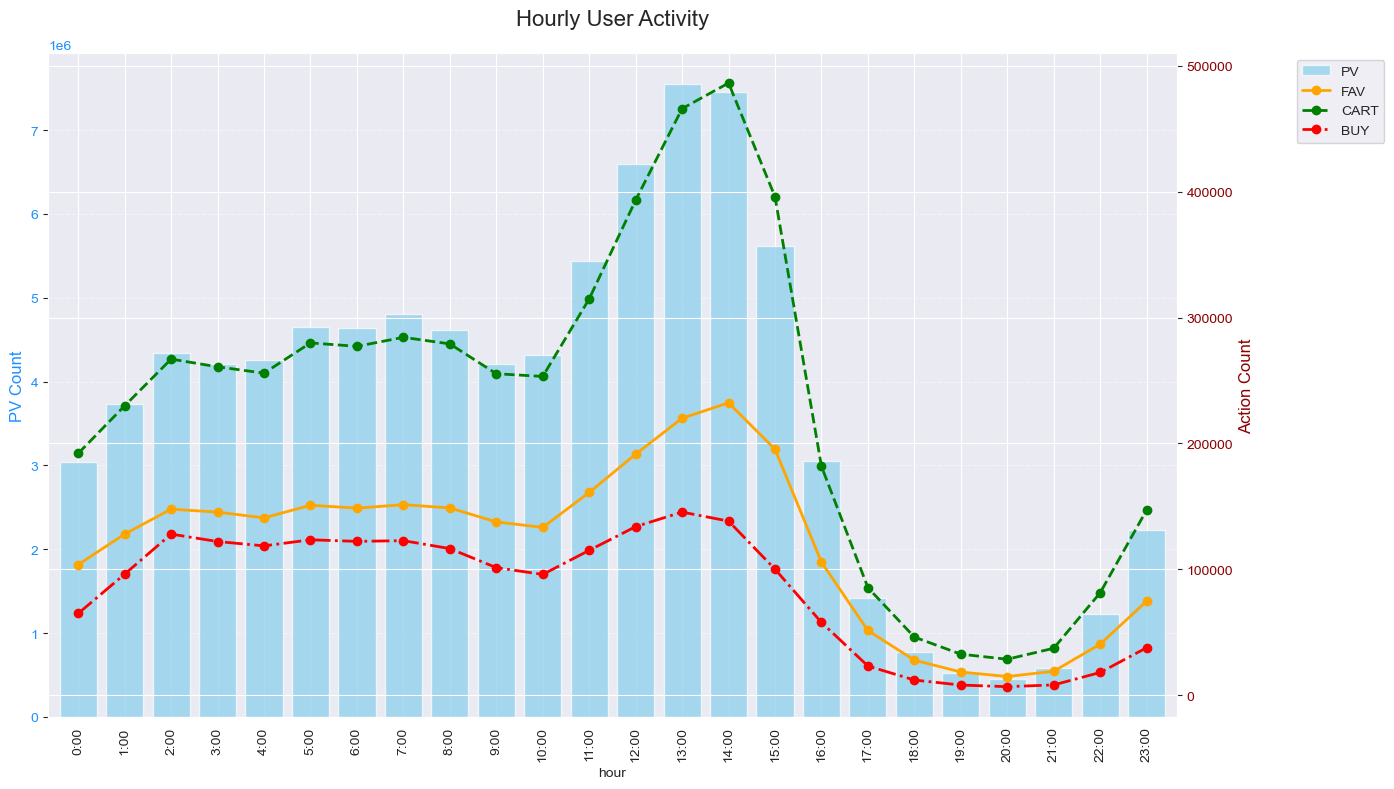

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/xiaozhuzhang/Desktop/阿里数分实习/week1/UserBehavior.csv.part',header=None)
df.columns = ['user_id', 'item_id', 'category_id','behavior_type', 'timestamp']
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s',errors='coerce')
df = df[(df['datetime'] >= 'xxxx-xx-xx') & (df['datetime'] <= 'xxxx-xx-xx')]
df['hour'] = df['datetime'].dt.hour

hourly_activity = df.groupby(['hour', 'behavior_type']).size().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))

hourly_activity['pv'].plot(
    kind='bar',
    ax=ax,
    color='skyblue',
    width=0.8,
    alpha=0.7,
    label='PV'
)
ax.set_ylabel('PV Count', fontsize=12, color='dodgerblue')
ax.tick_params(axis='y', labelcolor='dodgerblue')
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax2 = ax.twinx()
line_styles = {'fav': '-', 'cart': '--', 'buy': '-.'}
colors = {'fav': 'orange', 'cart': 'green', 'buy': 'red'}

for behavior in ['fav', 'cart', 'buy']:
    if behavior in hourly_activity.columns:
        hourly_activity[behavior].plot(
            kind='line',
            ax=ax2,
            color=colors[behavior],
            linestyle=line_styles[behavior],
            marker='o',
            markersize=6,
            linewidth=2,
            label=f'{behavior.upper()}'
        )
ax2.set_ylabel('Action Count', fontsize=12, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.1, 1))

plt.title('Hourly User Activity', pad=20, fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.xticks(range(24), [f'{h}:00' for h in range(24)], rotation=45)
plt.tight_layout()
plt.show()